In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

In [59]:
df = pd.read_csv("data-bank.csv")
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [61]:
df.isna().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

In [62]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [63]:
df['Bankrupt?'].value_counts(normalize=True)

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

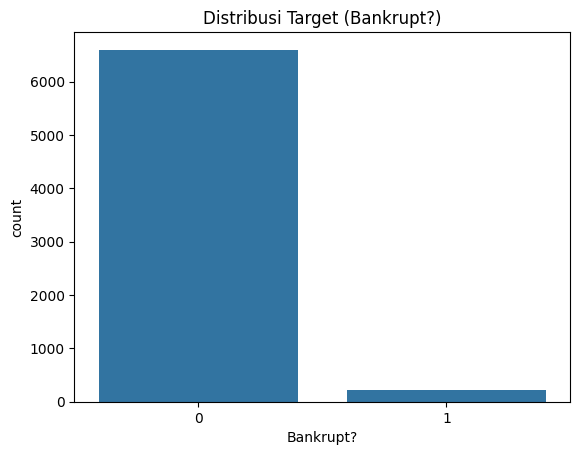

In [64]:
sns.countplot(data=df, x='Bankrupt?')
plt.title("Distribusi Target (Bankrupt?)")
plt.show()

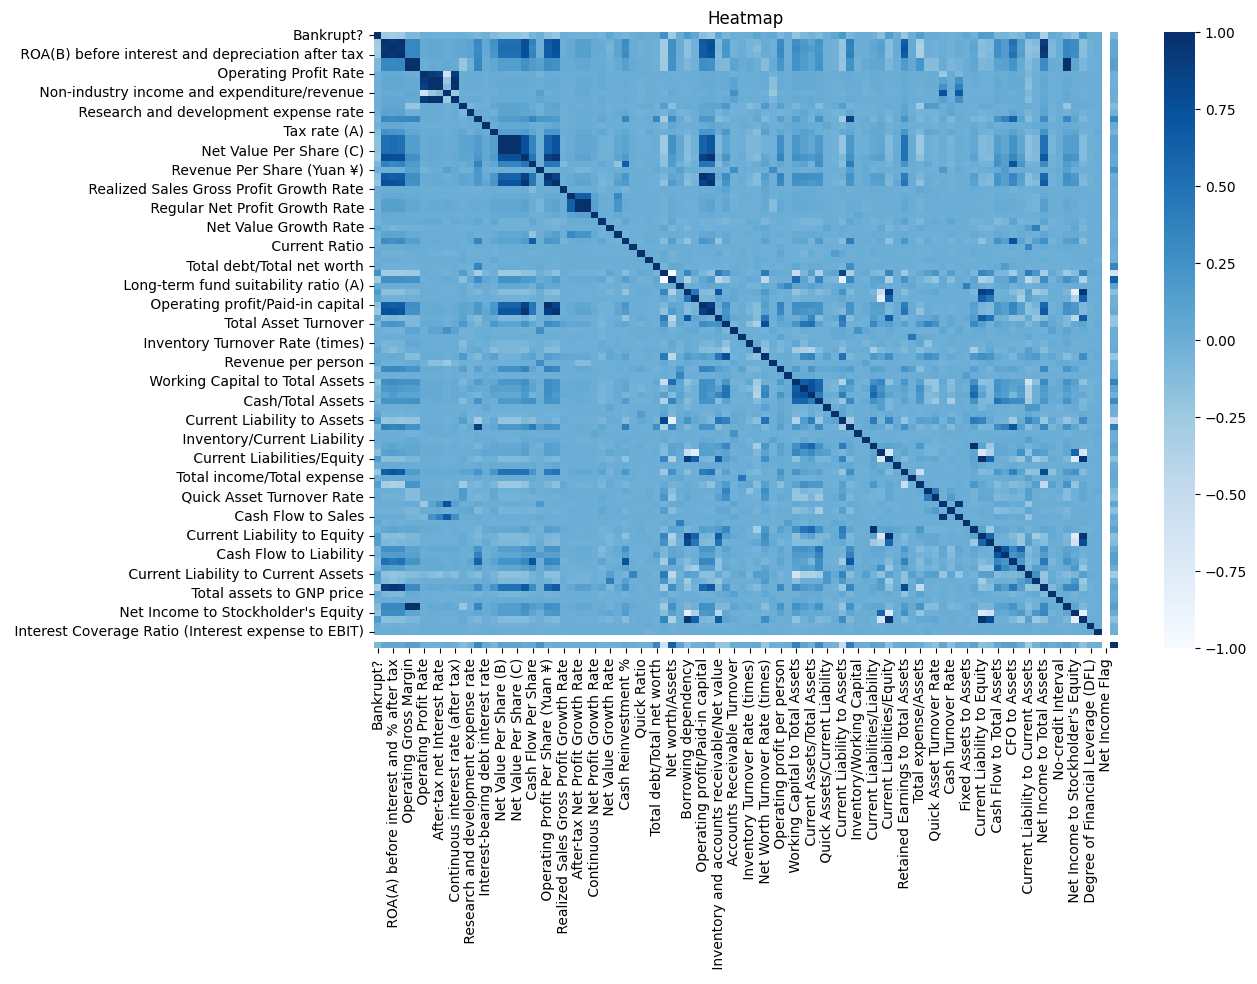

In [65]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="Blues")
plt.title("Heatmap")
plt.show()

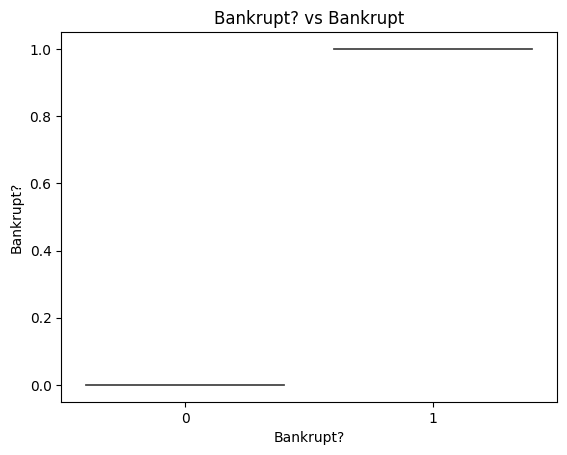

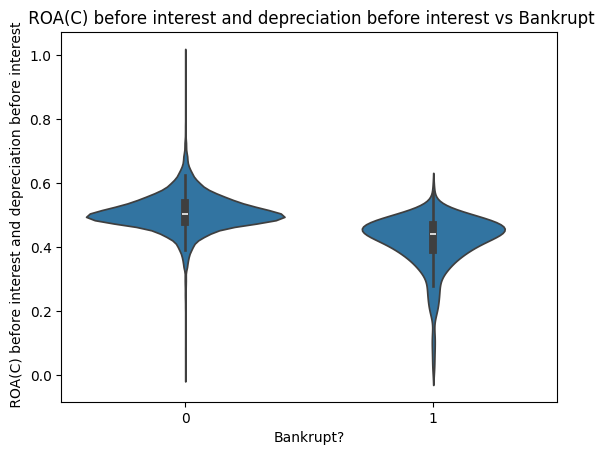

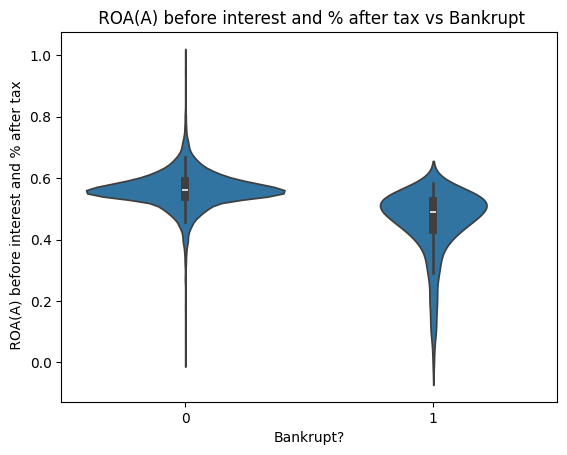

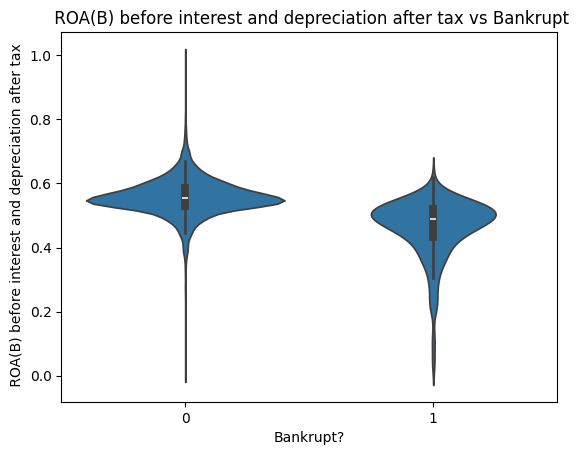

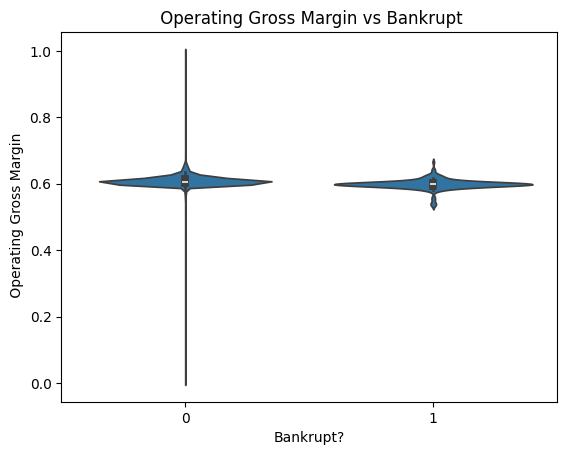

In [66]:
cols = df.columns[:5]
for col in cols:
    plt.figure()
    sns.violinplot(data=df, x="Bankrupt?", y=col)
    plt.title(f"{col} vs Bankrupt")
    plt.show()


In [67]:
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(     #split data buat testing
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [69]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.40      0.41      0.40        44

    accuracy                           0.96      1364
   macro avg       0.69      0.69      0.69      1364
weighted avg       0.96      0.96      0.96      1364



In [71]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1320
           1       0.71      0.23      0.34        44

    accuracy                           0.97      1364
   macro avg       0.84      0.61      0.67      1364
weighted avg       0.97      0.97      0.97      1364



In [72]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost Report")
print(classification_report(y_test, y_pred_xgb))


XGBoost Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1320
           1       0.70      0.36      0.48        44

    accuracy                           0.97      1364
   macro avg       0.84      0.68      0.73      1364
weighted avg       0.97      0.97      0.97      1364



In [73]:
models = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost Report": y_pred_xgb
}

for name, pred in models.items():
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    print(f"{name} -> Precision: {prec:.4f}, Recall: {rec:.4f}")

Decision Tree -> Precision: 0.4000, Recall: 0.4091
Random Forest -> Precision: 0.7143, Recall: 0.2273
XGBoost Report -> Precision: 0.6957, Recall: 0.3636


In [74]:
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp.head()

,Feature,Importance
89,Net Income to Stockholder's Equity,0.030435
29,Net Value Growth Rate,0.028835
18,Persistent EPS in the Last Four Seasons,0.023955
39,Borrowing dependency,0.023383
42,Net profit before tax/Paid-in capital,0.019852


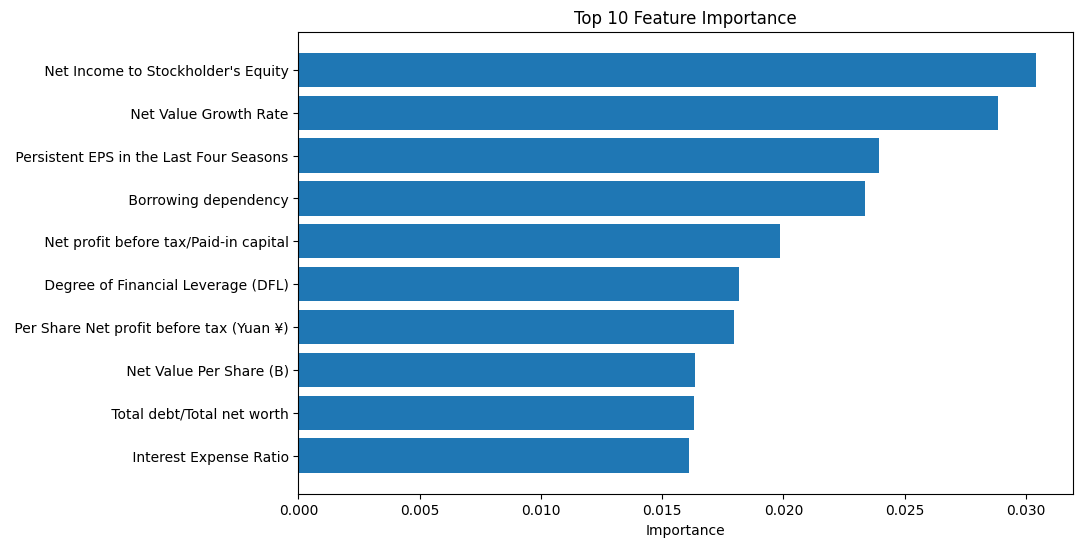

In [75]:
plt.figure(figsize=(10,6))
plt.barh(top["Feature"], top["Importance"])
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()



In [76]:
print("Model dengan Precision Tertinggi Adalah:")
for name, pred in models.items():
    prec = precision_score(y_test, pred)
    print(f"{name}: {prec:.4f}")

Model dengan Precision Tertinggi Adalah:
Decision Tree: 0.4000
Random Forest: 0.7143
XGBoost Report: 0.6957


In [77]:
pip install scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE

def train_random_search(model, param_dist, X, y, scoring='precision', n_iter=10, use_smote=False):
    """
    model: classifier
    param_dist: dict parameter untuk RandomizedSearchCV
    X, y: training data
    scoring: metric yang akan dioptimasi
    n_iter: jumlah kombinasi random
    use_smote: True untuk oversampling minor class
    """
    if use_smote:
        sm = SMOTE(random_state=42)
        X_res, y_res = sm.fit_resample(X, y)
    else:
        X_res, y_res = X, y
    
    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=scoring,
        cv=3,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    rs.fit(X_res, y_res)
    return rs.best_estimator_, rs

In [81]:
from xgboost import XGBClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_rf = {
'n_estimators': [300, 400, 500], # lebih banyak estimator
'max_depth': [8, 12, None], # lebih dalam
'min_samples_split': [2, 4, 6],
'min_samples_leaf':[1,2,4]
}
best_rf, rs_rf = train_random_search(rf, param_rf, X_train, y_train, scoring='precision', n_iter=20, use_smote=True)


# DecisionTree dengan fokus precision tinggi
dt = DecisionTreeClassifier(random_state=42)
param_dt = {
'max_depth': [6,8,10],
'min_samples_split':[2,4,6],
'min_samples_leaf':[1,2,4]
}
best_dt, rs_dt = train_random_search(dt, param_dt, X_train, y_train, scoring='precision', n_iter=15, use_smote=True)


# XGBoost optimasi precision tinggi
xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
param_xgb = {
'n_estimators':[200,400,600],
'max_depth':[5,6,7],
'learning_rate':[0.01,0.03,0.05],
'subsample':[0.8,0.9,1.0],
'colsample_bytree':[0.8,1.0],
'scale_pos_weight':[30] # sesuai imbalance
}
best_xgb, rs_xgb = train_random_search(xgb, param_xgb, X_train, y_train, scoring='precision', n_iter=20, use_smote=False)


# MLP Neural Network dengan layer lebih besar dan alpha lebih rendah
mlp = MLPClassifier(random_state=42, max_iter=1000)
param_mlp = {
'hidden_layer_sizes':[(100,50),(150,100),(200,100)],
'alpha':[0.00001,0.0001,0.001],
'learning_rate_init':[0.001,0.005]
}
best_mlp, rs_mlp = train_random_search(mlp, param_mlp, X_train, y_train, scoring='precision', n_iter=15, use_smote=True)


# Simpan models
models = {
'RandomForest': best_rf,
'DecisionTree': best_dt,
'XGBoost': best_xgb,
'MLP': best_mlp
}


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Winson\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:31:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fitting 3 folds for each of 15 candidates, totalling 45 fits



=== RandomForest ===
Threshold used: 0.5
ROC-AUC: 0.9460571625344353
              precision    recall  f1-score   support

           0     0.9862    0.9765    0.9813      1320
           1     0.4561    0.5909    0.5149        44

    accuracy                         0.9641      1364
   macro avg     0.7212    0.7837    0.7481      1364
weighted avg     0.9691    0.9641    0.9663      1364



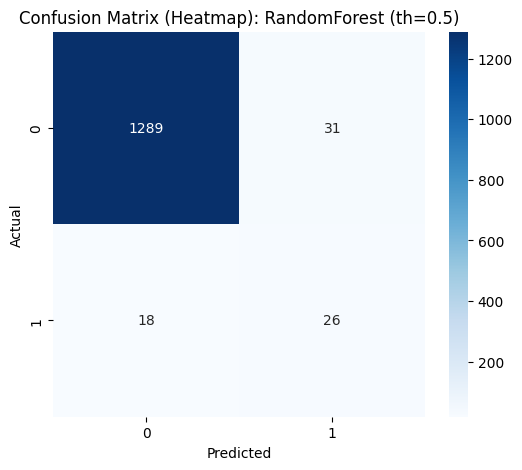


=== DecisionTree ===
Threshold used: 0.5
ROC-AUC: 0.8423725895316804
              precision    recall  f1-score   support

           0     0.9887    0.9258    0.9562      1320
           1     0.2344    0.6818    0.3488        44

    accuracy                         0.9179      1364
   macro avg     0.6115    0.8038    0.6525      1364
weighted avg     0.9643    0.9179    0.9366      1364



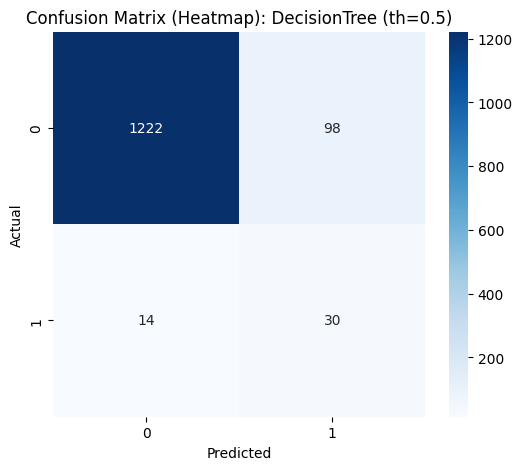


=== XGBoost ===
Threshold used: 0.5
ROC-AUC: 0.9569559228650137
              precision    recall  f1-score   support

           0     0.9819    0.9864    0.9841      1320
           1     0.5263    0.4545    0.4878        44

    accuracy                         0.9692      1364
   macro avg     0.7541    0.7205    0.7360      1364
weighted avg     0.9672    0.9692    0.9681      1364



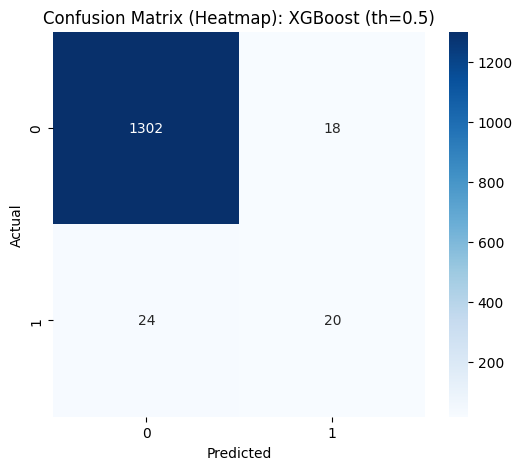


=== MLP ===
Threshold used: 0.5
ROC-AUC: 0.5800189393939394
              precision    recall  f1-score   support

           0     0.9734    0.9152    0.9434      1320
           1     0.0894    0.2500    0.1317        44

    accuracy                         0.8937      1364
   macro avg     0.5314    0.5826    0.5376      1364
weighted avg     0.9449    0.8937    0.9172      1364



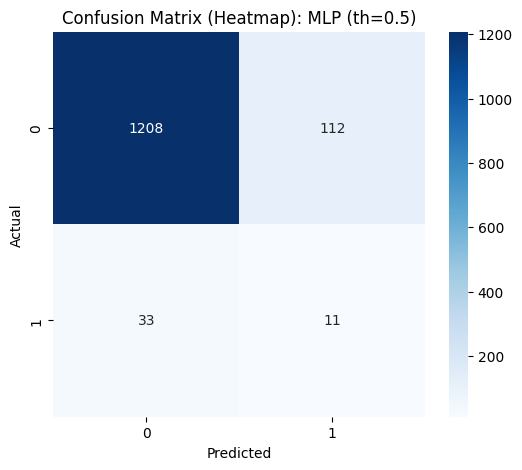

In [83]:
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def eval_model(model, X_test, y_test, name='model', threshold=0.5):
    try:
        y_prob = model.predict_proba(X_test)[:,1]
    except Exception:
        if hasattr(model, 'named_steps') and 'model' in model.named_steps:
            y_prob = model.named_steps['model'].predict_proba(X_test)[:,1]
        else:
            raise

    y_pred = (y_prob >= threshold).astype(int)

    print(f'\n=== {name} ===')
    print('Threshold used:', threshold)
    print('ROC-AUC:', roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred, digits=4))

    # === GANTI DIAGRAM DI SINI ===
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f'Confusion Matrix (Heatmap): {name} (th={threshold})')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return y_prob

# Evaluasi semua model
probs = {}
for name, m in models.items():
    try:
        probs[name] = eval_model(m, X_test, y_test, name, threshold=0.5)
    except Exception as e:
        print('Error evaluating', name, e)



=== RandomForest ===
Threshold used: 0.5
ROC-AUC: 0.9460571625344353
              precision    recall  f1-score   support

           0     0.9862    0.9765    0.9813      1320
           1     0.4561    0.5909    0.5149        44

    accuracy                         0.9641      1364
   macro avg     0.7212    0.7837    0.7481      1364
weighted avg     0.9691    0.9641    0.9663      1364



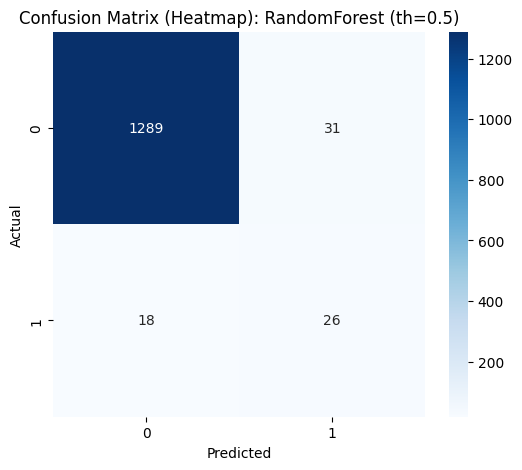


=== DecisionTree ===
Threshold used: 0.5
ROC-AUC: 0.8423725895316804
              precision    recall  f1-score   support

           0     0.9887    0.9258    0.9562      1320
           1     0.2344    0.6818    0.3488        44

    accuracy                         0.9179      1364
   macro avg     0.6115    0.8038    0.6525      1364
weighted avg     0.9643    0.9179    0.9366      1364



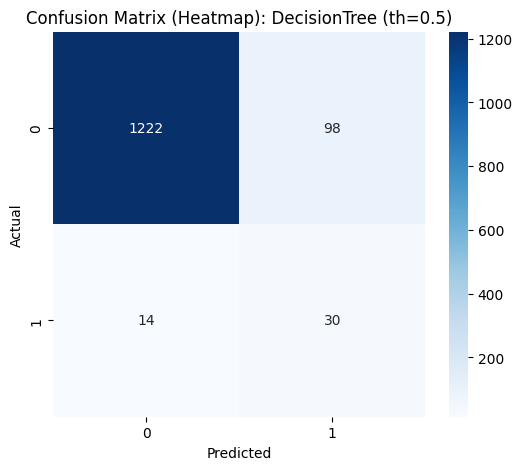


=== XGBoost ===
Threshold used: 0.5
ROC-AUC: 0.9569559228650137
              precision    recall  f1-score   support

           0     0.9819    0.9864    0.9841      1320
           1     0.5263    0.4545    0.4878        44

    accuracy                         0.9692      1364
   macro avg     0.7541    0.7205    0.7360      1364
weighted avg     0.9672    0.9692    0.9681      1364



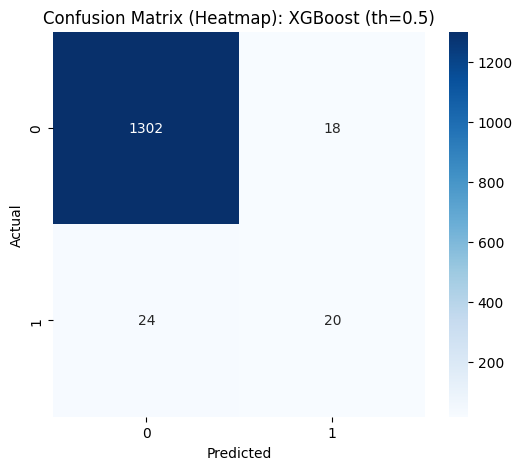


=== MLP ===
Threshold used: 0.5
ROC-AUC: 0.5800189393939394
              precision    recall  f1-score   support

           0     0.9734    0.9152    0.9434      1320
           1     0.0894    0.2500    0.1317        44

    accuracy                         0.8937      1364
   macro avg     0.5314    0.5826    0.5376      1364
weighted avg     0.9449    0.8937    0.9172      1364



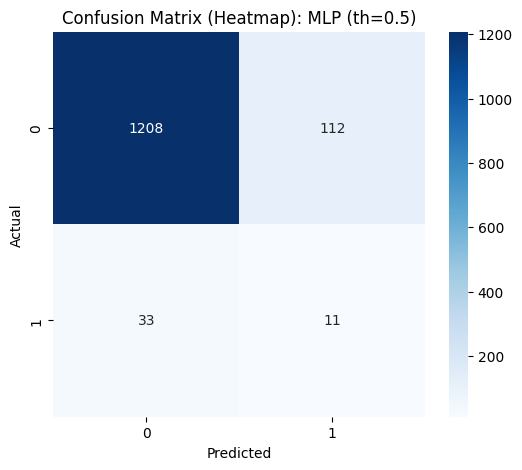

In [84]:
probs = {}
for name, m in models.items():
    try:
        probs[name] = eval_model(m, X_test, y_test, name, threshold=0.5)
    except Exception as e:
        print('Error evaluating', name, e)


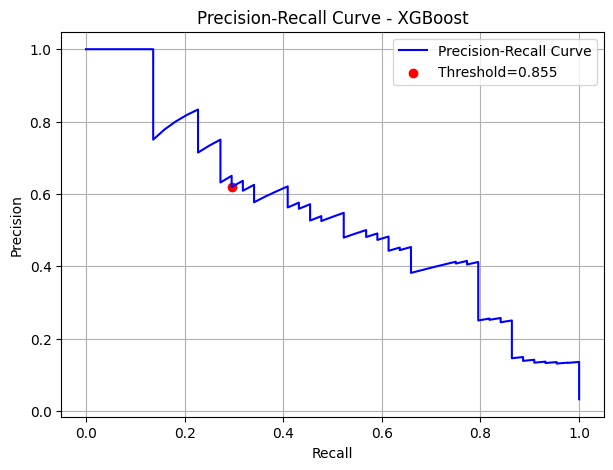

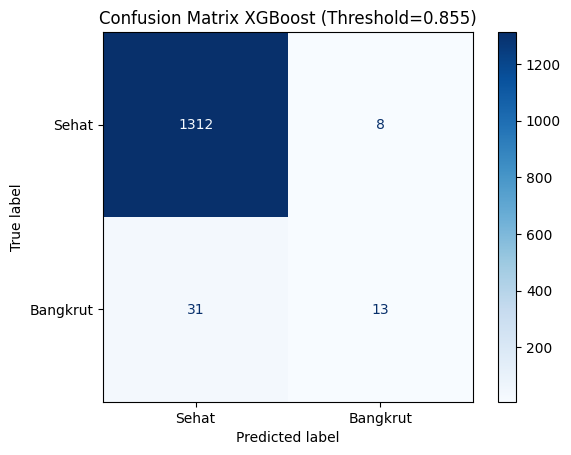

In [88]:
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

# Probabilitas prediksi
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

# Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,5))
plt.plot(recalls, precisions, label='Precision-Recall Curve', color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.grid(True)

# Tandai threshold optimal
optimal_thresh = 0.855
# Cari titik terdekat di curve
idx = (np.abs(thresholds - optimal_thresh)).argmin()
plt.scatter(recalls[idx], precisions[idx], color='r', label=f'Threshold={optimal_thresh}')
plt.legend()
plt.show()

# Confusion Matrix di threshold optimal
y_pred_opt = (y_prob_xgb >= optimal_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sehat', 'Bangkrut'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix XGBoost (Threshold={optimal_thresh})')
plt.show()


In [91]:
from sklearn.metrics import classification_report

precision_summary = {}

for name, m in models.items():
    try:
        y_prob = m.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
        precision = classification_report(y_test, y_pred, output_dict=True)['1']['precision']
        precision_summary[name] = precision
    except:
        pass

# Cetak
print("Model dengan Precision Tertinggi Adalah:")
for model, prec in precision_summary.items():
    print(f"{model}: {prec:.4f}")


Model dengan Precision Tertinggi Adalah:
RandomForest: 0.4561
DecisionTree: 0.2344
XGBoost: 0.5263
MLP: 0.0894
